# 1. Sensing and Low-Level Processing

- image processing (grayscale -> gaussian 3x3 -> sobel -> canny)

Result: image with edges detected
After: segmentation, feature extraction, classification

In [1]:
!pip install numpy matplotlib

In [4]:
from PIL import Image # Allowed ONLY for decoding the image to RGB [3]

def downscale(input_path, target_size=512):
    # 1. Decode the compressed image into raw RGB data
    img = Image.open(input_path).convert('RGB')
    pixels = img.load()
    orig_width, orig_height = img.size
    
    # Create a new blank 512x512 image array to act as our frame buffer
    out_img = Image.new('RGB', (target_size, target_size))
    out_pixels = out_img.load()
    
    # 2. Calculate the scaling ratios
    # This tells us how many pixels to "skip" in the original image 
    # for every 1 pixel in our new target image.
    x_ratio = orig_width / target_size
    y_ratio = orig_height / target_size
    
    # 3. Hand-crafted downscaling loop (Nearest Neighbor method)
    # We iterate exactly 512x512 times to fill our new frame
    for y in range(target_size):
        for x in range(target_size):
            
            # Map the 512x512 coordinates back to the original image's coordinates
            src_x = int(x * x_ratio)
            src_y = int(y * y_ratio)
            
            # Ensure we don't accidentally pull an index out of bounds
            src_x = min(src_x, orig_width - 1)
            src_y = min(src_y, orig_height - 1)
            
            # Extract the raw RGB values from the original pixel 
            # and map them to the new 512x512 output
            r, g, b = pixels[src_x, src_y] # type: ignore
            out_pixels[x, y] = (r, g, b) # type: ignore
            
    print(f"Successfully downscaled {orig_width}x{orig_height} to 512x512!")
    return out_img


Successfully downscaled 4096x3072 to 512x512!


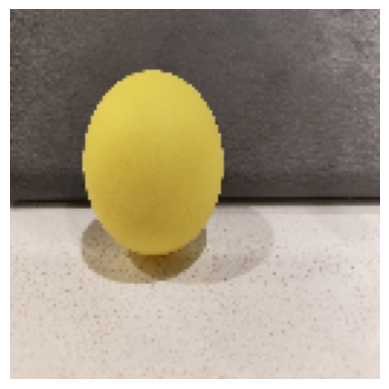

In [5]:
import numpy as np
import matplotlib.pyplot as plt

img = np.array(downscale("frame1.jpg", 128))

# show img
plt.imshow(img)
plt.axis('off')
plt.show()

In [6]:
# define utils

def convolution(image, kernel):
    # Get dimensions of the image and kernel
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape
    
    # Calculate padding for the image
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2
    
    # Pad the image with zeros on the borders
    padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant')
    
    # Prepare an output array to store the convolved result
    output = np.zeros_like(image)
    
    # Perform convolution
    for i in range(image_height):
        for j in range(image_width):
            # Extract the region of interest
            region = padded_image[i:i+kernel_height, j:j+kernel_width]
            # Apply the kernel to the region and sum the result
            output[i, j] = np.sum(region * kernel)
    
    return output

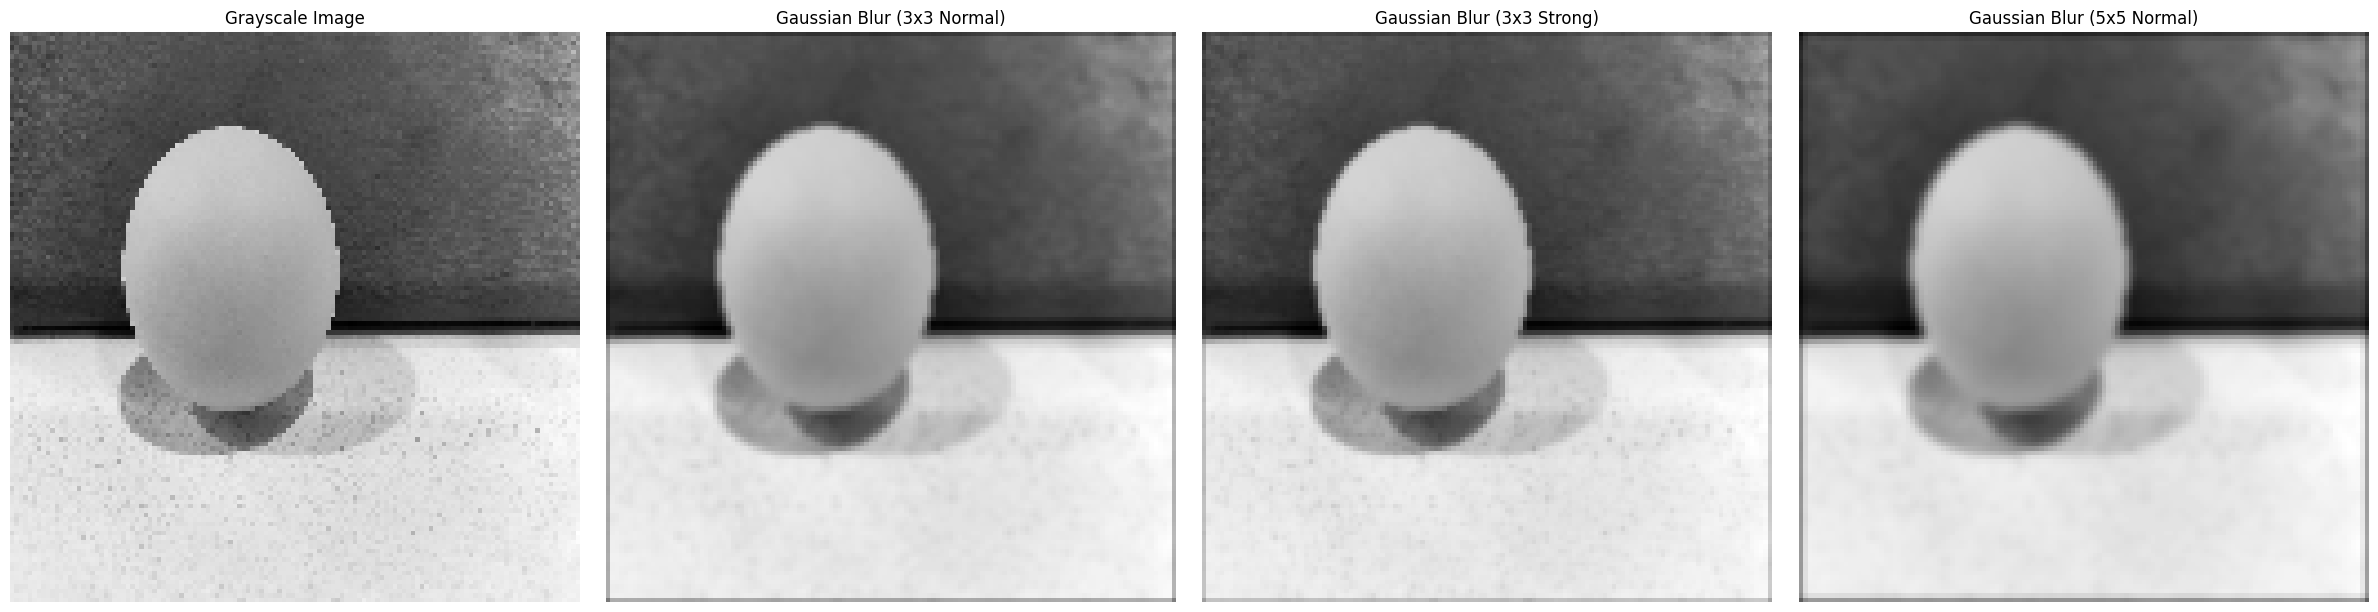

In [7]:
# grayscale
def gray(img):
  # bias towards green and red
  return 0.3 * img[:, :, 0] + 0.5 * img[:, :, 1] + 0.2 * img[:, :, 2]

def gaussian_blur(img, kernel):
  return convolution(img, kernel)

gray_img = gray(img)
gaussian_3x3_normal = np.array([[1, 2, 1],
                                  [2, 4, 2],
                                  [1, 2, 1]]) / 16

gaussian_3x3_strong = np.array([[1, 4, 1],
                                  [4, 16, 4],
                                    [1, 4, 1]]) / 36

gaussian_5x5_normal = np.array([[1, 4, 6, 4, 1],
                                  [4, 16, 24, 16, 4],
                                  [6, 24, 36, 24, 6],
                                  [4, 16, 24, 16, 4],
                                  [1, 4, 6, 4, 1]]) / 256


# use existing gray_img if already available
gray_img = gray_img if 'gray_img' in globals() else gray(img)

blur_normal = gaussian_blur(gray_img, gaussian_3x3_normal)
blur_strong = gaussian_blur(gray_img, gaussian_3x3_strong)
blur_5x5 = gaussian_blur(gray_img, gaussian_5x5_normal)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Grayscale Image')
axes[0].axis('off')

axes[1].imshow(blur_normal, cmap='gray')
axes[1].set_title('Gaussian Blur (3x3 Normal)')
axes[1].axis('off')

axes[2].imshow(blur_strong, cmap='gray')
axes[2].set_title('Gaussian Blur (3x3 Strong)')
axes[2].axis('off')

axes[3].imshow(blur_5x5, cmap='gray')
axes[3].set_title('Gaussian Blur (5x5 Normal)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

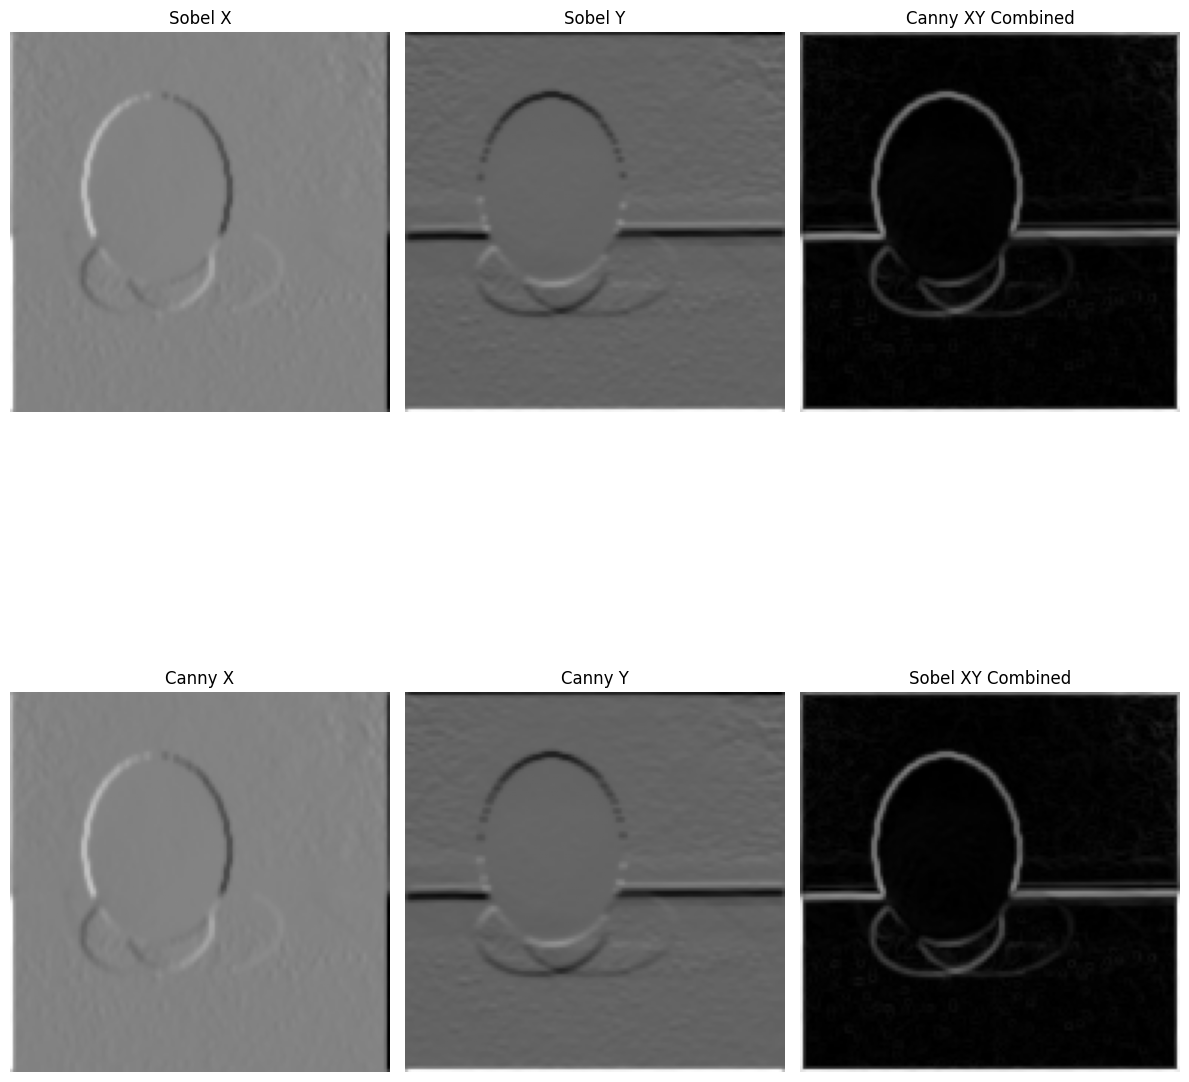

In [6]:
# sobel
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[1, 2, 1],
                    [0, 0, 0],
                    [-1, -2, -1]])

sobel_y_strong = np.array([[2, 4, 2],
                    [0, 0, 0],
                    [-2, -4, -2]])

# canny
canny_x = np.array([[-1, 0, 1],
                    [-1, 0, 1],
                    [-1, 0, 1]])
canny_y = np.array([[1, 1, 1],
                    [0, 0, 0],
                    [-1, -1, -1]])

# combined xy
def combine_edge_xy(edge_x, edge_y):
    return np.sqrt(edge_x**2 + edge_y**2)

# plot 2x2 grid - sobel 
fig, axes = plt.subplots(2, 3, figsize=(12, 16))
axes[0, 0].imshow(convolution(blur_strong, sobel_x), cmap='gray')
axes[0, 0].set_title('Sobel X')
axes[0, 0].axis('off')
axes[0, 1].imshow(convolution(blur_strong, sobel_y), cmap='gray')
axes[0, 1].set_title('Sobel Y')
axes[0, 1].axis('off')
axes[1, 0].imshow(convolution(blur_strong, canny_x), cmap='gray')
axes[1, 0].set_title('Canny X')
axes[1, 0].axis('off')
axes[1, 1].imshow(convolution(blur_strong, canny_y), cmap='gray')
axes[1, 1].set_title('Canny Y')
axes[1, 1].axis('off')
axes[0, 2].imshow(combine_edge_xy(convolution(blur_strong, canny_x), convolution(blur_strong, canny_y)), cmap='gray')
axes[0, 2].set_title('Canny XY Combined')
axes[0, 2].axis('off')
axes[1, 2].imshow(combine_edge_xy(convolution(blur_strong, sobel_x), convolution(blur_strong, sobel_y)), cmap='gray')
axes[1, 2].set_title('Sobel XY Combined')
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

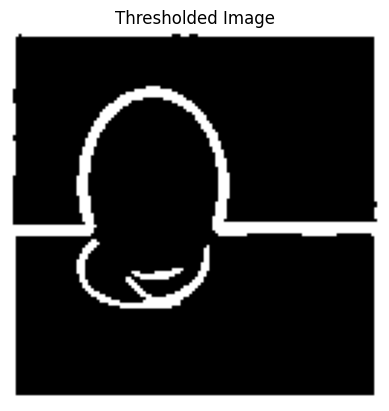

In [7]:
# thresh sobel Y out

def threshold(image, thresh_value):
  # Create a binary image based on the threshold value
  binary_image = np.zeros_like(image)
  binary_image[image >= thresh_value] = 255
  return binary_image

thresh = threshold(combine_edge_xy(convolution(blur_5x5, sobel_x), convolution(blur_5x5, sobel_y)), 100)
plt.imshow(thresh, cmap='gray')
plt.title('Thresholded Image')
plt.axis('off')
plt.show()

In [8]:
# Method 2: Color-based segmentation using HSV

# Convert the image to HSV color space
def rgb_to_hsv(rgb_image):
    # Normalize RGB values to [0, 1]
    rgb_normalized = rgb_image / 255.0
    r, g, b = rgb_normalized[:,:,0], rgb_normalized[:,:,1], rgb_normalized[:,:,2]
    
    cmax = np.max(rgb_normalized, axis=2)
    cmin = np.min(rgb_normalized, axis=2)
    delta = cmax - cmin
    
    # Hue calculation
    hue = np.zeros_like(cmax)
    hue[delta != 0] = np.where(cmax[delta != 0] == r[delta != 0], (g[delta != 0] - b[delta != 0]) / delta[delta != 0],
                                np.where(cmax[delta != 0] == g[delta != 0], (b[delta != 0] - r[delta != 0]) / delta[delta != 0] + 2,
                                         (r[delta != 0] - g[delta != 0]) / delta[delta != 0] + 4))
    hue = (hue * 60) % 360
    
    # Saturation calculation
    saturation = np.zeros_like(cmax)
    saturation[cmax != 0] = delta[cmax != 0] / cmax[cmax != 0]
    
    # Value calculation
    value = cmax
    
    return np.stack((hue, saturation, value), axis=2)
  
hsv_img = rgb_to_hsv(img)

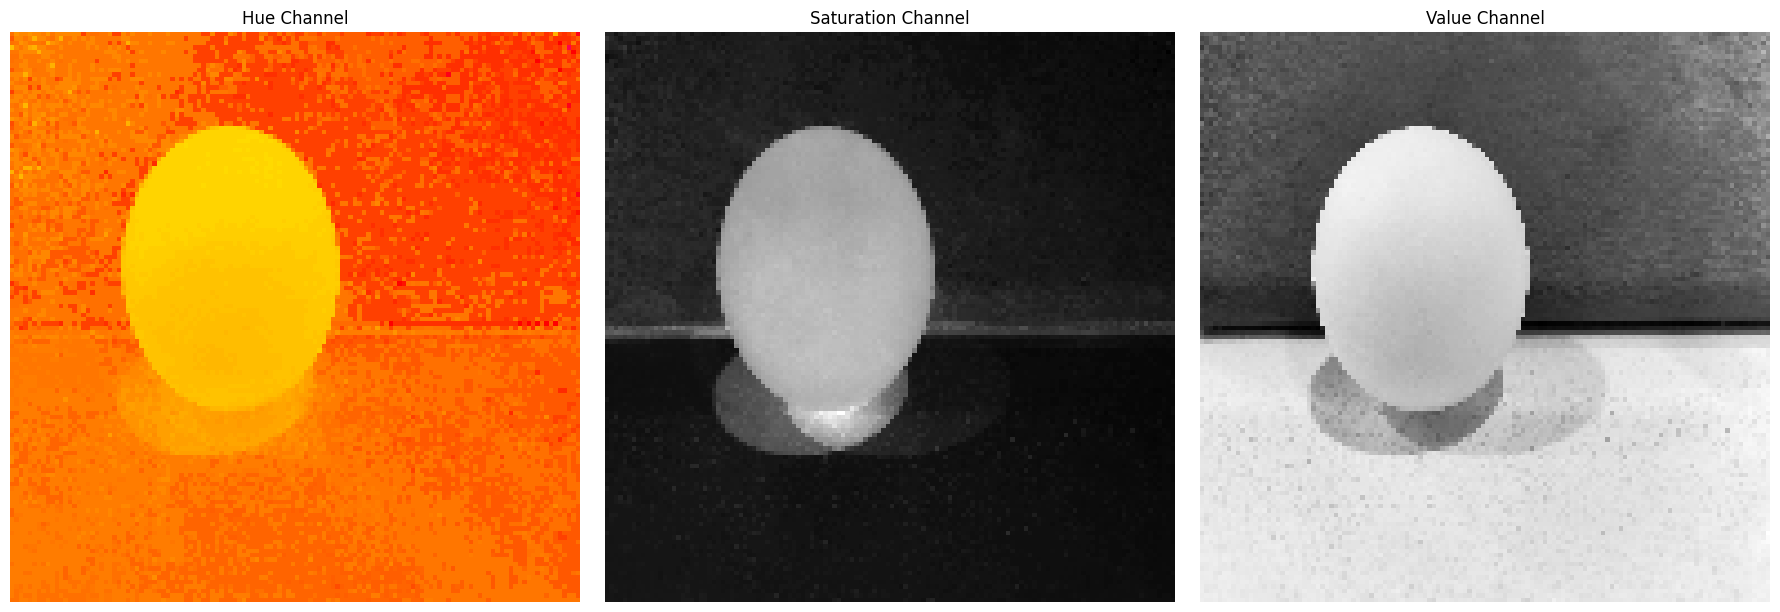

In [ ]:
# segmentation of the hsv image based on hue
def segment_hue(hsv_image, hue_range):
  hue = hsv_image[:,:,0]
  mask = (hue >= hue_range[0]) & (hue <= hue_range[1])
  segmented_image = np.zeros_like(hsv_image)
  segmented_image[mask] = hsv_image[mask]
  return segmented_image

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(hsv_img[:,:,0], cmap='hsv')
axes[0].set_title('Hue Channel')
axes[0].axis('off')
axes[1].imshow(hsv_img[:,:,1], cmap='gray')
axes[1].set_title('Saturation Channel')
axes[1].axis('off')
axes[2].imshow(hsv_img[:,:,2], cmap='gray')
axes[2].set_title('Value Channel')
axes[2].axis('off')
plt.tight_layout()
plt.show()

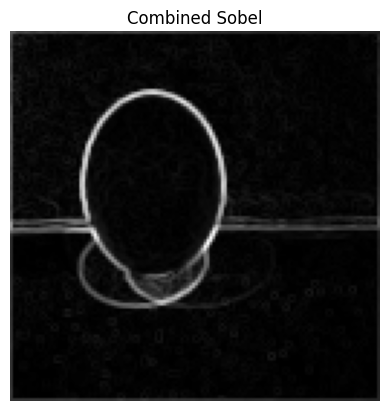

In [31]:
# sobel
sobel_x_result = convolution(hsv_img[:,:,1], sobel_x)
sobel_y_result = convolution(hsv_img[:,:,1], sobel_y)

# show
plt.imshow(combine_edge_xy(sobel_x_result, sobel_y_result), cmap='gray')
plt.title('Combined Sobel')
plt.axis('off')
plt.show()

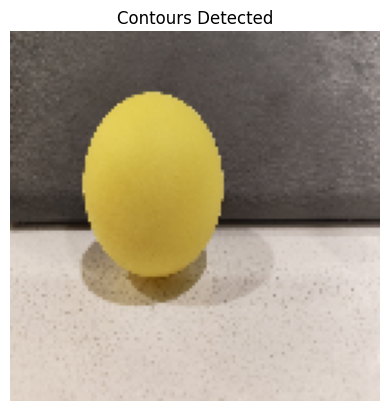

In [11]:
# find contours - using pure python - based on hue
def find_contours(segmented_image):
    # This is a very basic contour detection algorithm that looks for edges in the segmented image
    contours = []
    for y in range(1, segmented_image.shape[0] - 1):
        for x in range(1, segmented_image.shape[1] - 1):
            if segmented_image[y, x, 0] != 0: # Check if the pixel is part of the segmented region
                # Check the 8-connected neighbors
                if (segmented_image[y-1, x-1, 0] == 0 or segmented_image[y-1, x, 0] == 0 or segmented_image[y-1, x+1, 0] == 0 or
                    segmented_image[y, x-1, 0] == 0 or segmented_image[y, x+1, 0] == 0 or
                    segmented_image[y+1, x-1, 0] == 0 or segmented_image[y+1, x, 0] == 0 or segmented_image[y+1, x+1, 0] == 0):
                    contours.append((x, y))
    return contours

# apply gaussian blur to each rgb channel then hsv 
hsv_img_blurred = np.zeros_like(hsv_img)
for i in range(3):
    hsv_img_blurred[:,:,i] = gaussian_blur(hsv_img[:,:,i], gaussian_5x5_normal)
  
# Example usage
hue_range = (30, 90) # Example hue range for green objects
segmented_image = segment_hue(hsv_img_blurred, hue_range)
contours = find_contours(segmented_image)
# Plot the contours on the original image
plt.imshow(img)
plt.scatter([c[0] for c in contours], [c[1] for c
  in contours], color='red', s=1)
plt.title('Contours Detected')
plt.axis('off')
plt.show()

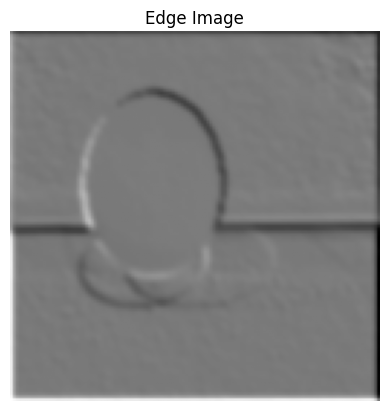

In [12]:
# show
plt.imshow(convolution(gaussian_blur(gray_img, gaussian_5x5_normal), sobel_x) + convolution(gaussian_blur(gray_img, gaussian_5x5_normal), sobel_y), cmap='gray')
plt.title('Edge Image')
plt.axis('off')
plt.show()

In [13]:
def hough_circle_optimized(edges, radius_range):
    height, width = edges.shape
    accumulator = np.zeros((height, width, radius_range[1] - radius_range[0]), dtype=np.uint64)
    
    # Precompute sin/cos for theta values
    theta_step = 10
    theta_vals = np.deg2rad(np.arange(0, 360, theta_step))
    cos_t = np.cos(theta_vals)
    sin_t = np.sin(theta_vals)
    
    # Get edge pixel coordinates
    ys, xs = np.where(edges > 0)
    
    for x, y in zip(xs, ys):
        for r in range(radius_range[0], radius_range[1]):
            for i in range(len(theta_vals)):
                a = int(x - r * cos_t[i])
                b = int(y - r * sin_t[i])
                if 0 <= a < width and 0 <= b < height:
                    accumulator[b, a, r - radius_range[0]] += 1
    
    return accumulator

edges = convolution(gaussian_blur(gray_img, gaussian_5x5_normal), sobel_x) + convolution(gaussian_blur(gray_img, gaussian_5x5_normal), sobel_y)
accumulator = hough_circle_optimized(edges, (10, 50))

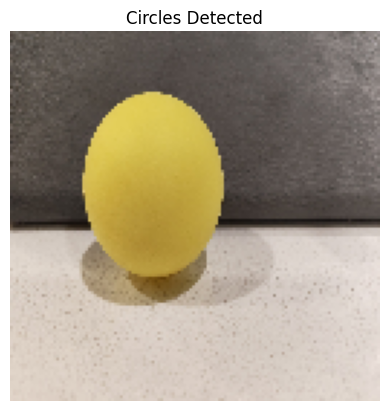

In [14]:
# Find circles based on accumulator peaks
def find_circles(accumulator, threshold):
    circles = []
    for r in range(accumulator.shape[2]):
        for y in range(accumulator.shape[0]):
            for x in range(accumulator.shape[1]):
                if accumulator[y, x, r] > threshold:
                    circles.append((x, y, r + 10)) # r + 10 to get the actual radius
    return circles
  
circles = find_circles(accumulator, 100)
# Plot the circles on the original image
plt.imshow(img)
for circle in circles:
    x, y, r = circle
    circle_patch = plt.Circle((x, y), r, color='red', fill=False)
    plt.gca().add_patch(circle_patch)
plt.title('Circles Detected')
plt.axis('off')
plt.show()

In [15]:
print("FUCK")

FUCK


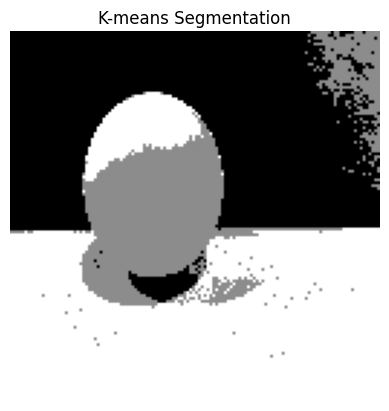

In [16]:
import numpy as np

def kmeans(data, k=3, max_iter=50):
    n_samples, n_features = data.shape
    
    # random initial centers
    idx = np.random.choice(n_samples, k, replace=False)
    centers = data[idx]

    for _ in range(max_iter):
        # compute distances
        distances = np.linalg.norm(data[:, None] - centers[None, :], axis=2)

        # assign clusters
        labels = np.argmin(distances, axis=1)

        # recompute centers
        new_centers = np.array([
            data[labels == i].mean(axis=0) if np.any(labels == i) else centers[i]
            for i in range(k)
        ])

        if np.allclose(new_centers, centers):
            break

        centers = new_centers

    return labels, centers
  
  
# find circles in gray(img) using k-means
gray_img_flat = gray(img).flatten().reshape(-1, 1)
labels, centers = kmeans(gray_img_flat, k=3)
segmented_img = centers[labels].reshape(gray(img).shape)
plt.imshow(segmented_img, cmap='gray')
plt.title('K-means Segmentation')
plt.axis('off')
plt.show()


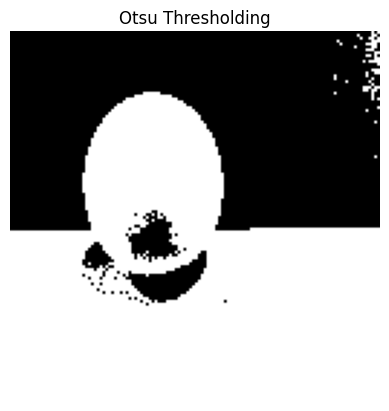

In [17]:
# otsu
def otsu_threshold(image):
  pixel_counts = np.bincount(image.flatten())
  total_pixels = image.size
  
  current_max, threshold = 0, 0
  sum_total, sum_foreground = 0, 0
  weight_background, weight_foreground = 0, 0
  
  for i in range(len(pixel_counts)):
      sum_total += i * pixel_counts[i]
  
  for i in range(len(pixel_counts)):
    weight_background += pixel_counts[i]
    if weight_background == 0:
      continue
    
    weight_foreground = total_pixels - weight_background
    if weight_foreground == 0:
      break
    
    sum_foreground += i * pixel_counts[i]
    
    mean_background = sum_foreground / weight_background
    mean_foreground = (sum_total - sum_foreground) / weight_foreground
    
    between_class_variance = weight_background * weight_foreground * (mean_background - mean_foreground) ** 2
    
    if between_class_variance > current_max:
      current_max = between_class_variance
      threshold = i
          
  return threshold


otsu_thresh_value = otsu_threshold(gray_img.astype(np.uint8))
binary_image_otsu = np.zeros_like(gray_img)
binary_image_otsu[gray_img >= otsu_thresh_value] = 255
plt.imshow(binary_image_otsu, cmap='gray')
plt.title('Otsu Thresholding')
plt.axis('off')
plt.show()

# 2. Feature Extraction

- Blob detection

After: 

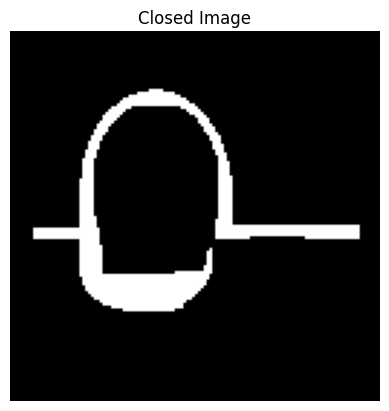

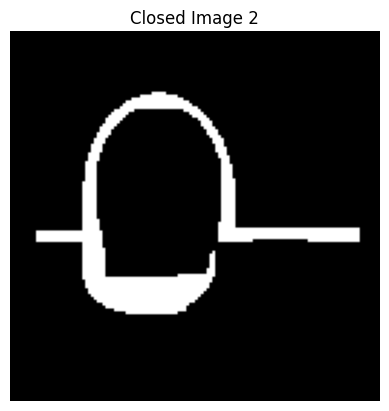

In [18]:
# morphology, connect edges - pure implementation

# dilation
def dilation(image, structure=None):
  if structure is None:
    structure = np.ones((3, 3), dtype=np.uint8)  # Default to a 3x3 square structuring element
  
  # Pad the image to handle borders
  pad_height = structure.shape[0] // 2
  pad_width = structure.shape[1] // 2
  padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant')
  
  dilated = np.zeros_like(image)
  
  for i in range(image.shape[0]):
    for j in range(image.shape[1]):
      # Extract the region of interest
      region = padded_image[i:i+structure.shape[0], j:j+structure.shape[1]]
      # If any pixel in the region is set and corresponds to the structuring element, set the output pixel
      if np.any(region * structure):
        dilated[i, j] = 255
  
  return dilated
  
# erosion
def erosion(image, structure=None):
  if structure is None:
      structure = np.ones((3, 3), dtype=np.uint8)  # Default to a 3x3 square structuring element
  
  # Pad the image to handle borders
  pad_height = structure.shape[0] // 2
  pad_width = structure.shape[1] // 2
  padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant')
  
  eroded = np.zeros_like(image)
  
  for i in range(image.shape[0]):
    for j in range(image.shape[1]):
      # Extract the region of interest
      region = padded_image[i:i+structure.shape[0], j:j+structure.shape[1]]
      # If all pixels in the region that correspond to the structuring element are set, set the output pixel
      if np.all(region * structure):
        eroded[i, j] = 255
  
  return eroded

# closing
def morphological_closing(image, structure=None):
  if structure is None:
    structure = np.ones((3, 3), dtype=np.uint8)  # Default to a 3x3 square structuring element
  
  # Dilation
  dilated = dilation(image, structure)
  
  # Erosion
  closed = erosion(dilated, structure)
  
  return closed

# opening
def morphological_opening(image, structure=None):
  if structure is None:
    structure = np.ones((3, 3), dtype=np.uint8)  # Default to a 3x3 square structuring element
  
  # Erosion
  eroded = erosion(image, structure)
  
  # Dilation
  opened = dilation(eroded, structure)
  
  return opened


# apply closing to the thresholded image
closed_image = morphological_closing(thresh, structure=np.ones((16, 16), dtype=np.uint8))
plt.imshow(closed_image, cmap='gray')
plt.title('Closed Image')
plt.axis('off')
plt.show()

# again
closed_image_2 = morphological_closing(closed_image, structure=np.ones((16, 16), dtype=np.uint8))
plt.imshow(closed_image_2, cmap='gray')
plt.title('Closed Image 2')
plt.axis('off')
plt.show()

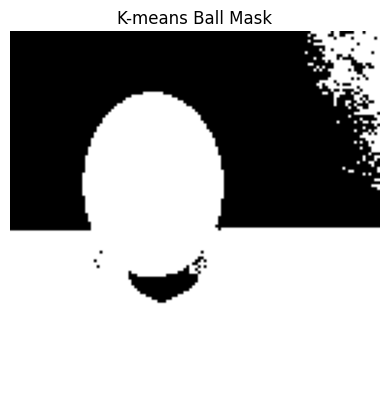

In [19]:
# # centers shape = (k,3)

# brightness = centers.mean(axis=1)

# # egg clusters tend to be mid/high brightness
# egg_clusters = np.where(brightness > brightness.mean())[0]

# mask = np.isin(labels.reshape(h,w), egg_clusters)

gray_img = gray(img)

gray_img_flat = gray_img.flatten().reshape(-1,1)

labels, centers = kmeans(gray_img_flat, k=3)

labels_img = labels.reshape(gray_img.shape)

# cluster brightness
brightness = centers.flatten()

# choose brighter clusters (egg is brighter)
ball_clusters = np.argsort(centers.flatten())[-2:]

ball_mask = np.isin(labels_img, ball_clusters)

plt.imshow(ball_mask, cmap='gray')
plt.title('K-means Ball Mask')
plt.axis('off')
plt.show()

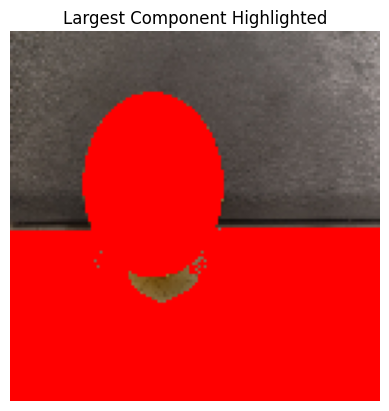

In [20]:
def largest_component(mask):
    h, w = mask.shape
    visited = np.zeros_like(mask, dtype=bool)
    
    largest = []
    
    for y in range(h):
        for x in range(w):
            if mask[y,x] and not visited[y,x]:
                
                stack = [(y,x)]
                component = []
                visited[y,x] = True
                
                while stack:
                    cy, cx = stack.pop()
                    component.append((cy,cx))
                    
                    for dy, dx in [(-1,0),(1,0),(0,-1),(0,1)]:
                        ny, nx = cy+dy, cx+dx
                        
                        if 0<=ny<h and 0<=nx<w:
                            if mask[ny,nx] and not visited[ny,nx]:
                                visited[ny,nx] = True
                                stack.append((ny,nx))
                
                if len(component) > len(largest):
                    largest = component

    clean = np.zeros_like(mask)
    for y,x in largest:
        clean[y,x] = 1
        
    return clean
  
  
largest_ball = largest_component(ball_mask)
# overlay
overlay = img.copy()
for y in range(overlay.shape[0]):
    for x in range(overlay.shape[1]):
        if largest_ball[y,x]:
            overlay[y,x] = [255,0,0]  # Highlight the largest component in red
plt.imshow(overlay)
plt.title('Largest Component Highlighted')
plt.axis('off')
plt.show() 

Center: (60.89, 87.43), Radius: 40.34


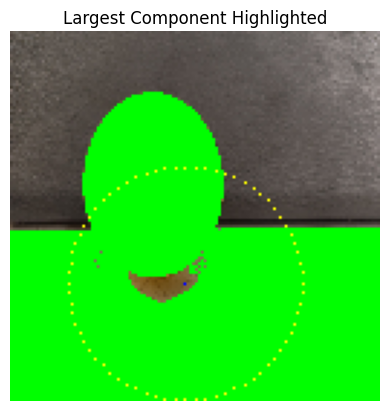

In [ ]:
clean_mask = largest_ball.astype(bool)
ys, xs = np.where(clean_mask)

cx = xs.mean()
cy = ys.mean()

radius = np.mean(np.sqrt((xs-cx)**2 + (ys-cy)**2))

#overlay
overlay = img.copy()
for y in range(overlay.shape[0]):
    for x in range(overlay.shape[1]):
        if largest_ball[y,x]:
            overlay[y,x] = [0,255,0]  # Highlight the largest component in red  

print(f"Center: ({cx:.2f}, {cy:.2f}), Radius: {radius:.2f}")

# center is in blue

overlay[int(cy), int(cx)] = [0,0,255]

# radius in yellow

for angle in range(0, 360, 5):
    rad = np.deg2rad(angle)
    x = int(cx + radius * np.cos(rad))
    y = int(cy + radius * np.sin(rad))
    if 0 <= x < overlay.shape[1] and 0 <= y < overlay.shape[0]:
        overlay[y, x] = [255,255,0]

plt.imshow(overlay)
plt.title('Largest Component Highlighted')
plt.axis('off')
plt.show()

In [32]:
def extract_segments(edges, threshold=50):
    h, w = edges.shape
    visited = np.zeros((h, w), dtype=bool)

    segments = []

    for y in range(h):
        for x in range(w):

            if edges[y, x] > threshold and not visited[y, x]:

                stack = [(y, x)]
                segment = []

                visited[y, x] = True

                while stack:
                    cy, cx = stack.pop()
                    segment.append((cy, cx))

                    for ny, nx in [
                        (cy-1,cx),(cy+1,cx),(cy,cx-1),(cy,cx+1),
                        (cy-1,cx-1),(cy-1,cx+1),(cy+1,cx-1),(cy+1,cx+1)
                    ]:
                        if 0 <= ny < h and 0 <= nx < w:
                            if edges[ny,nx] > threshold and not visited[ny,nx]:
                                visited[ny,nx] = True
                                stack.append((ny,nx))

                segments.append(segment)

    return segments

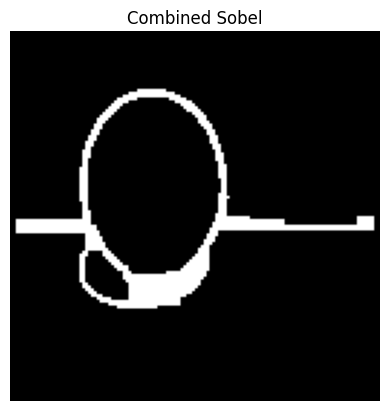

In [ ]:
sobel_x_result = convolution(hsv_img[:,:,1], sobel_x)
sobel_y_result = convolution(hsv_img[:,:,1], sobel_y)
edges = combine_edge_xy(sobel_x_result, sobel_y_result)
edges = threshold(edges, edges.mean() + edges.std())
edges = morphological_closing(edges, structure=np.ones((5, 5), dtype=np.uint8))

# show
plt.imshow(edges, cmap='gray')
plt.title('Combined Sobel')
plt.axis('off')
plt.show()

[[(20, 44), (21, 45), (22, 46), (21, 47), (22, 48), (21, 49), (22, 50), (21, 51), (22, 52), (21, 53), (22, 54), (23, 55), (22, 56), (23, 57), (24, 58), (25, 59), (26, 60), (27, 61), (26, 62), (27, 63), (28, 64), (29, 65), (30, 66), (31, 67), (32, 68), (33, 69), (34, 70), (35, 69), (36, 70), (37, 71), (38, 70), (39, 71), (40, 72), (41, 71), (42, 72), (43, 73), (44, 72), (45, 73), (46, 74), (47, 73), (48, 74), (49, 73), (50, 74), (51, 73), (52, 74), (53, 73), (54, 74), (55, 73), (56, 74), (57, 75), (58, 74), (59, 73), (60, 74), (61, 73), (62, 74), (63, 73), (64, 74), (65, 75), (66, 76), (67, 77), (68, 78), (67, 79), (68, 80), (67, 81), (68, 82), (67, 83), (68, 84), (67, 85), (68, 86), (67, 87), (68, 88), (67, 89), (68, 90), (67, 91), (68, 92), (67, 93), (68, 94), (67, 95), (68, 96), (67, 97), (68, 98), (67, 99), (68, 100), (67, 101), (68, 102), (67, 103), (68, 104), (67, 105), (68, 106), (67, 107), (68, 108), (67, 109), (68, 110), (67, 111), (68, 112), (67, 113), (68, 114), (67, 115), (6

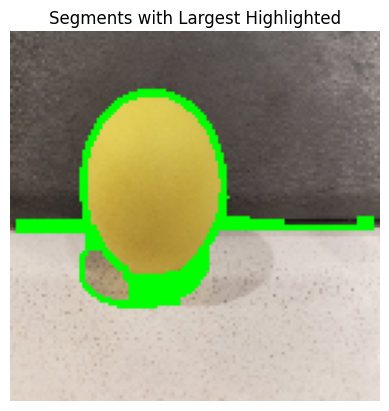

In [49]:
# Edges
sobel_x_result = convolution(hsv_img[:,:,1], sobel_x)
sobel_y_result = convolution(hsv_img[:,:,1], sobel_y)
edges = combine_edge_xy(sobel_x_result, sobel_y_result)
edges = threshold(edges, edges.mean() + edges.std())
edges = morphological_closing(edges, structure=np.ones((5, 5), dtype=np.uint8))

# segments
segments = extract_segments(edges)

print(segments)

# Largest segment
largest_segment = max(segments, key=len)

# display all segments w/ largest segment having a different color, w/ radius of each segment, overlayed on image opacity 80

overlay = img.copy()
for segment in segments:
    for y, x in segment:
        overlay[y, x] = [255, 0, 0]  # Red for all segments
        # 
for y, x in largest_segment:
    overlay[y, x] = [0, 255, 0]  # Green for largest segment
plt.imshow(overlay)
plt.title('Segments with Largest Highlighted')
plt.axis('off')
plt.show()


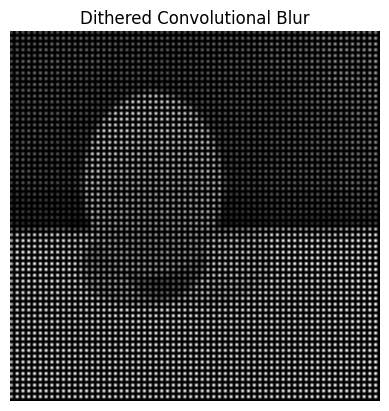

In [8]:
import numpy as np  
# dither convolutional blur - using a 3x3 kernel, but only applying it to every other pixel, and skipping the rest (dithering) - to speed up the convolution while still getting a blur effect

dither_conv = np.array([[1, 2, 1],
                        [2, 4, 2],
                        [1, 2, 1]]) / 16

def dither_convolution(image, kernel):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape
    
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2
    
    padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant')
    
    output = np.zeros_like(image)
    
    for i in range(0, image_height, 2):  # Dither: process every other pixel
        for j in range(0, image_width, 2):
            region = padded_image[i:i+kernel_height, j:j+kernel_width]
            output[i, j] = np.sum(region * kernel)
    
    return output
  
  
dither_blurred = dither_convolution(gray(img), dither_conv)
plt.imshow(dither_blurred, cmap='gray')
plt.title('Dithered Convolutional Blur')
plt.axis('off')
plt.show()